In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)  # prevent wrapping

data = pd.read_csv('../data/raw/dataset.csv', index_col=0)
print(data.shape)
data.head()

(114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
AUDIO_FEATURES = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
LOG_FEATURES = ['speechiness', 'acousticness', 'instrumentalness', 'liveness']

data_audio = data[AUDIO_FEATURES + ['track_genre']].copy()
print(data_audio.shape)
data_audio.head()

(114000, 9)


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
0,0.676,0.4610,0.1430,0.0322,0.000001,0.3580,0.715,87.917,acoustic
1,0.420,0.1660,0.0763,0.9240,0.000006,0.1010,0.267,77.489,acoustic
2,0.438,0.3590,0.0557,0.2100,0.000000,0.1170,0.120,76.332,acoustic
3,0.266,0.0596,0.0363,0.9050,0.000071,0.1320,0.143,181.740,acoustic
4,0.618,0.4430,0.0526,0.4690,0.000000,0.0829,0.167,119.949,acoustic


In [5]:
print('Before: ', data_audio.shape)
print('Null Counts:', data_audio.isnull().sum().sum())
data_audio = data_audio.dropna()
print('After: ', data_audio.shape)

Before:  (114000, 9)
Null Counts: 0
After:  (114000, 9)


In [7]:
data_transformed = data_audio.copy()

data_transformed[LOG_FEATURES] = np.log1p(data_transformed[LOG_FEATURES]) 

# Quick sanity check — compare before/after stats for one feature
print("=== speechiness ===")
print("Before:", data_audio["speechiness"].describe().round(4).to_dict())
print("After: ", data_transformed["speechiness"].describe().round(4).to_dict())

=== speechiness ===
Before: {'count': 114000.0, 'mean': 0.0847, 'std': 0.1057, 'min': 0.0, '25%': 0.0359, '50%': 0.0489, '75%': 0.0845, 'max': 0.965}
After:  {'count': 114000.0, 'mean': 0.0775, 'std': 0.0824, 'min': 0.0, '25%': 0.0353, '50%': 0.0477, '75%': 0.0811, 'max': 0.6755}


In [8]:
scaler = StandardScaler()

tracks_scaled = scaler.fit_transform(data_transformed[AUDIO_FEATURES])

print("Shape: ", tracks_scaled.shape)
print("Per-feature mean (should be ~0): ", tracks_scaled.mean(axis=0).round(4))
print("Per-feature std (should be ~1): ", tracks_scaled.std(axis=0).round(4))

Shape:  (114000, 8)
Per-feature mean (should be ~0):  [ 0. -0.  0.  0.  0. -0.  0. -0.]
Per-feature std (should be ~1):  [1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:
pca = PCA(n_components=2)
tracks_pca = pca.fit_transform(tracks_scaled)

print("PCA output shape: ", tracks_pca.shape)
print("Variance explained per component: ", pca.explained_variance_ratio_.round(4))
print("Total variance explained: ", pca.explained_variance_ratio_.sum().round(4))

PCA output shape:  (114000, 2)
Variance explained per component:  [0.2726 0.1802]
Total variance explained:  0.4528


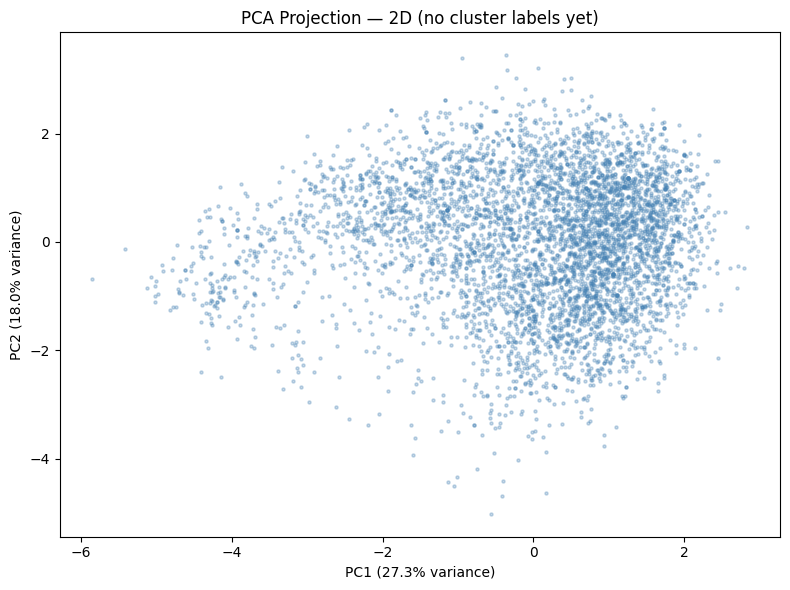

In [10]:
# Sample 5000 points for visibility
sample_idx = np.random.choice(len(tracks_pca), size=5000, replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(
    tracks_pca[sample_idx, 0],
    tracks_pca[sample_idx, 1],
    alpha=0.3, s=5, color="steelblue"
)
plt.title("PCA Projection — 2D (no cluster labels yet)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("../outputs/figures/04_pca_projection.png", dpi=150)
plt.show()

In [11]:
np.save("../data/processed/tracks_scaled.npy", tracks_scaled)
np.save("../data/processed/tracks_pca.npy", tracks_pca)
np.save("../data/processed/track_genres.npy", data_transformed["track_genre"].values)

print("Saved:")
print("  tracks_scaled.npy  →", tracks_scaled.shape)
print("  tracks_pca.npy     →", tracks_pca.shape)
print("  track_genres.npy   →", data_transformed["track_genre"].values.shape)

Saved:
  tracks_scaled.npy  → (114000, 8)
  tracks_pca.npy     → (114000, 2)
  track_genres.npy   → (114000,)


## Preprocessing Key Takeaways

Step | What happened
--- | ---
Column selection | 20 → 9 columns (8 audio features + genre retained for validation)
Null check | Zero nulls in audio feature columns — confirmed clean
log1p transform | Applied to speechiness, acousticness, instrumentalness, liveness
StandardScaler | All 8 features at mean≈0, std=1
PCA (viz only) | 45.3% variance in 2D — structure visible, clustering runs on full 8D matrix
Saved | tracks_scaled.npy, tracks_pca.npy, track_genres.npy